##Karar Ağaçları

Amaç:
 1. iris veri seti kullanarak karar ağaçları ile sınıflandırma problemi çözmek

Veri Seti:
 1. 3 farklı çiçek sınıfı(etiketi): setosa, versicolor, virginica
 2. Her örnek için 4 öznitelik: sepal length, sepal width, petal length , petal width
 3. 150 tane örnek veri içermektedir.

 Adımlar:
  1. veri setini yükle
  2. feature (x) ve target(y)  değerleri ayır
  3. eğitim ve test veri setlerinin oluşturulması
  4. karar ağacı modelinin oluşturulması ve eğitimi
  5. test verisi üzerinden tahmin yapılması
  6. model başarımının accuracy ile ölçülmesi
  7. cunfusion matrix oluşturulması ve görselleştirilmesi
  8. karar ağacının görselleştirilmesi
  9. future importance incelenmesi





In [1]:
#gerekli kütüphaneleri içeriye aktar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
from datetime import date
# 1. iris veri seti yükle
iris = load_iris()

df = pd.DataFrame(
    data = iris.data,
    columns = iris.feature_names
)

df["target"] = iris.target
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
# 2. feature ve target verilerini ayır
x= iris.data
y= iris.target

In [7]:
# 3. train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [8]:
# 4.karar ağacı modeli oluşturulması
tree_clf = DecisionTreeClassifier(criterion= "gini", max_depth= 3, random_state=42)
tree_clf.fit(x_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [9]:
# 5.test
y_pred = tree_clf.predict(x_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [10]:
y_test

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [11]:
# 6.accuracy
accuracy = accuracy_score(y_pred, y_test)
accuracy


1.0

In [12]:
# 7. confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

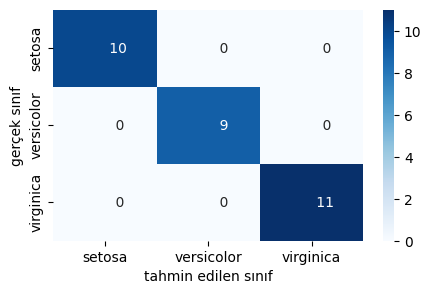

In [20]:
# conf matrix görselleştirilmesi
plt.figure(figsize = (5,3))
sns.heatmap(
    conf_matrix,
    annot = True,
    fmt = "8",
    cmap = "Blues",
    xticklabels = iris.target_names,
    yticklabels = iris.target_names,
)
plt.xlabel("tahmin edilen sınıf")
plt.ylabel("gerçek sınıf")
plt.show()

[Text(0.375, 0.875, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]\nclass = versicolor'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'petal length (cm) <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'petal width (cm) <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.75, 0.375, 'petal width (cm) <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.5\nsamples = 8\nvalue = [0, 4, 4]\nclass = versicolor'),
 Text(0.875, 0.125, 'gini = 0.056\nsamples = 35\nvalue = [0, 1, 34]\nclass = virginica')]

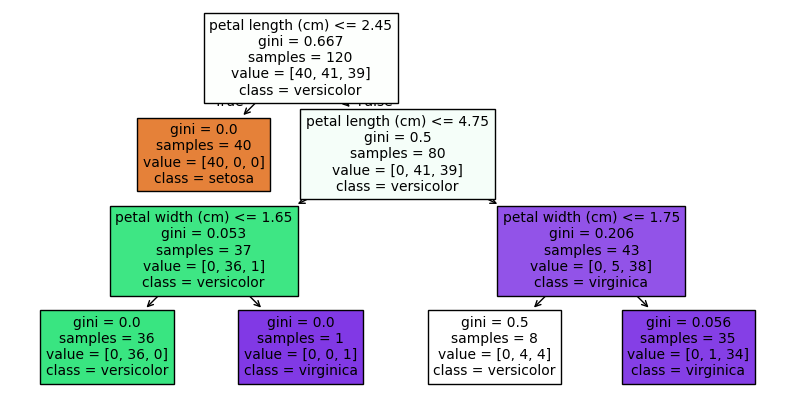

In [27]:
# 8.karar ağacını görselleştirme
plt.figure( figsize = (10,5))
plot_tree(
    tree_clf,
    filled= True,
    feature_names = iris.feature_names,
    class_names = list(iris.target_names)

)

In [30]:
# future importance
tree_clf.feature_importances_

array([0.        , 0.        , 0.93462632, 0.06537368])